# Random Forest Baseline Model – Kitchener Water Pipe Failure Prediction

#### Purpose

This notebook builds a **baseline Random Forest classification model** using the **Kitchener model-ready dataset** to predict whether a water pipe has experienced a break (`has_break`).

A **classification model** is used instead of regression because it aligns better with the goal of building a **risk identification system**.
Rather than predicting a continuous failure rate, the model estimates whether a pipe is likely to fall into a break-risk category, which is more practical for future prioritisation and maintenance planning.

#### Expected outputs
By the end of this notebook, this Random Forest workflow should deliver:

- A **baseline pipe failure risk model** that predicts whether a water pipe has experienced a break (`has_break`)
- A **methodologically clean modelling process** using separate train, validation, and test sets
- A **tuned final Random Forest classifier** suitable for fair comparison with other models
- **Final evaluation metrics on the unseen test set**, including:
  - ROC-AUC
  - PR-AUC
  - Precision
  - Recall
  - F1-score
- A **confusion matrix** to show how well the model identifies break vs no-break pipes
- A **feature importance ranking** to highlight the strongest drivers of pipe failure risk
- A **probability-based risk output** that can be used later to:
  - rank pipes by risk level
  - support maintenance prioritisation
  - provide an interpretable foundation for future LLM-based maintenance recommendation workflows

#### Note
- **Training set** → fit the model
- **Validation set** → tune and compare model performance
- **Test set** → final unbiased evaluation

This makes the Random Forest results easier to compare fairly with other models in the later stage.

## 1. Load dataset, define features and target variable

In [3]:
# Import all required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)

In [4]:
# Load dataset
df = pd.read_csv('../data/processed/kitchener_model_ready.csv')

# Quick check
print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df['has_break'].value_counts())
print(df['has_break'].value_counts(normalize=True))

Shape: (16163, 20)
  pressure_zone category  pipe_size material  lined lined_material  \
0         KIT 6  TREATED        450       DI      0           NONE   
1         KIT 4  TREATED        300       DI      0           NONE   
2         KIT 6  TREATED        450       DI      0           NONE   
3         KIT 6  TREATED        450       DI      0           NONE   
4         KIT 6  TREATED        450       DI      0           NONE   

  acquisition             ownership  bridge_main  criticality  \
0     DONATED  DUAL CITY AND REGION            0          6.0   
1   PURCHASED                REGION            0          7.0   
2     DONATED  DUAL CITY AND REGION            0          7.0   
3     DONATED  DUAL CITY AND REGION            0          6.0   
4     DONATED  DUAL CITY AND REGION            0          6.0   

   rel_cleaning_area rel_cleaning_subarea  undersized  shallow_main  \
0                  6                    8           0             0   
1                  1       

Before splitting the data, we separate the target variable (`has_break`) from the input features.

This creates the feature matrix `X` and target vector `y` that will be used for train, validation, and test splitting in the next step.

In [6]:
# Separate input features (X) and target variable (y)
X = df.drop(columns=['has_break'])   # All columns except target
y = df['has_break']                  # Target column: whether the pipe has had a break

# Quick shape check
print("X shape:", X.shape)
print("y shape:", y.shape)

# Check target distribution
print("\nTarget distribution:")
print(y.value_counts())

X shape: (16163, 19)
y shape: (16163,)

Target distribution:
has_break
0    14929
1     1234
Name: count, dtype: int64


## 2. Split dataset

The data is split into **70% train**, **15% validation**, and **15% test** sets.  
Stratified splitting is used to ensure the `has_break` class distribution remains consistent across all subsets.

In [8]:
SEED = 42

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# Quick check
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (11314, 19)
Validation shape: (2424, 19)
Test shape: (2425, 19)

Train target distribution:
has_break
0    0.923634
1    0.076366
Name: proportion, dtype: float64

Validation target distribution:
has_break
0    0.92368
1    0.07632
Name: proportion, dtype: float64

Test target distribution:
has_break
0    0.923711
1    0.076289
Name: proportion, dtype: float64


Before encoding, we identify which columns are categorical and which are numerical.  

This helps ensure that only categorical variables are one-hot encoded, while numerical features are kept in their original form.

In [10]:
# Identify categorical and numerical columns from the training set
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

# Print the detected column groups
print("Categorical columns:", cat_cols)
print("\nNumber of categorical columns:", len(cat_cols))

print("\nNumerical columns:", num_cols)
print("\nNumber of numerical columns:", len(num_cols))

Categorical columns: ['pressure_zone', 'category', 'material', 'lined_material', 'acquisition', 'ownership', 'rel_cleaning_subarea']

Number of categorical columns: 7

Numerical columns: ['pipe_size', 'lined', 'bridge_main', 'criticality', 'rel_cleaning_area', 'undersized', 'shallow_main', 'condition_score', 'oversized', 'cleaned', 'shape__length', 'pipe_age']

Number of numerical columns: 12


## 3. Encode Categorical Features

The Random Forest model requires all inputs to be numeric. To prepare the dataset for modelling, the categorical columns are converted into numeric indicator columns using one-hot encoding.

The validation and test sets are then aligned to the training feature space to ensure all three sets have the exact same columns.

In [12]:
# One-hot encode categorical columns in each split
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_val_enc = pd.get_dummies(X_val, columns=cat_cols, drop_first=False)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

# Align validation and test columns to match the training columns exactly
# Any category not present in validation/test but present in training will be filled with 0
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Confirm encoded shapes
print("Encoded train shape:", X_train_enc.shape)
print("Encoded validation shape:", X_val_enc.shape)
print("Encoded test shape:", X_test_enc.shape)

# Confirm column order matches exactly
print("\nColumn alignment check:")
print("Validation matches training:", list(X_val_enc.columns) == list(X_train_enc.columns))
print("Test matches training:", list(X_test_enc.columns) == list(X_train_enc.columns))

Encoded train shape: (11314, 102)
Encoded validation shape: (2424, 102)
Encoded test shape: (2425, 102)

Column alignment check:
Validation matches training: True
Test matches training: True


## 4. Train baseline Random Forest model

Now that the data is fully prepared, the next step is to train a baseline Random Forest classifier.

This baseline model gives an initial reference point before any hyperparameter tuning.
class_weight='balanced' is used to help the model pay more attention to the minority class (has_break = 1).

In [14]:
# Build a baseline Random Forest classifier
rf_baseline = RandomForestClassifier(
    n_estimators=300,         # number of trees in the forest
    max_depth=None,           # allow trees to grow fully unless limited by other settings
    min_samples_split=2,      # minimum samples required to split an internal node
    min_samples_leaf=1,       # minimum samples required at a leaf node
    max_features='sqrt',      # use square root of total features at each split
    class_weight='balanced',  # handle class imbalance by weighting minority class more
    random_state=SEED,        # reproducibility
    n_jobs=-1                 # use all CPU cores for faster training
)

# Train the baseline model on the training set
rf_baseline.fit(X_train_enc, y_train)

print("Baseline Random Forest training complete.")

Baseline Random Forest training complete.


## 5. Evaluate model on validation set

The baseline model is first evaluated on the validation set, not the test set.
This gives an initial view of model performance before tuning, while keeping the test set untouched for final evaluation later.

Because the target is imbalanced, the most important metrics here are:

PR-AUC for minority class performance
Recall to see how many break pipes are identified
Precision to see how reliable positive predictions are
F1-score for balance between precision and recall

In [16]:
# Predict class labels on the validation set
y_val_pred = rf_baseline.predict(X_val_enc)

# Predict class probabilities for the positive class (has_break = 1)
y_val_prob = rf_baseline.predict_proba(X_val_enc)[:, 1]

# Print key validation metrics
print("Baseline Validation ROC-AUC:", roc_auc_score(y_val, y_val_prob))
print("Baseline Validation PR-AUC:", average_precision_score(y_val, y_val_prob))
print("Baseline Validation Precision:", precision_score(y_val, y_val_pred))
print("Baseline Validation Recall:", recall_score(y_val, y_val_pred))
print("Baseline Validation F1:", f1_score(y_val, y_val_pred))

# Full classification report
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

Baseline Validation ROC-AUC: 0.9884552708134665
Baseline Validation PR-AUC: 0.9634931435706999
Baseline Validation Precision: 0.9712643678160919
Baseline Validation Recall: 0.9135135135135135
Baseline Validation F1: 0.9415041782729805

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2239
           1       0.97      0.91      0.94       185

    accuracy                           0.99      2424
   macro avg       0.98      0.96      0.97      2424
weighted avg       0.99      0.99      0.99      2424



#### Interpretation

The baseline Random Forest already performs strongly on the validation set.

It shows excellent class separation and strong minority-class performance, with particularly high precision and a recall above 0.91.

This suggests the current feature set contains strong signal for identifying pipe break risk, although some break cases are still being missed.

## 6. Tune hyperparameters

To improve the baseline model further, the next step is to test several hyperparameter combinations on the validation set.

The best model will be selected using validation PR-AUC, since the target is imbalanced and the main interest is identifying break-risk pipes effectively.

In [19]:
# Define a small but useful parameter grid for tuning
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

best_score = -1
best_params = None
best_model = None

# Loop through all parameter combinations
for params in ParameterGrid(param_grid):
    rf = RandomForestClassifier(
        **params,
        random_state=SEED,
        n_jobs=-1
    )
    
    # Train model on training set only
    rf.fit(X_train_enc, y_train)
    
    # Predict probabilities on validation set
    y_val_prob = rf.predict_proba(X_val_enc)[:, 1]
    
    # Use PR-AUC as the tuning metric
    score = average_precision_score(y_val, y_val_prob)
    
    # Keep track of the best model
    if score > best_score:
        best_score = score
        best_params = params
        best_model = rf

print("Best Validation PR-AUC:", best_score)
print("Best Parameters:", best_params)

Best Validation PR-AUC: 0.9661440920028425
Best Parameters: {'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


#### Tuning summary

Hyperparameter tuning produced a small improvement in validation PR-AUC, increasing it from **0.9635** to **0.9661**.  
This suggests the baseline Random Forest was already strong, but a slightly deeper and larger forest (`max_depth=20`, `n_estimators=400`) performs best on the validation set.

## 7. Retrain the model on training + validation set

After selecting the best hyperparameters, the final model is retrained using the combined training and validation data.

This allows the model to learn from more labelled examples before the final evaluation, while the test set remains untouched and reserved for a single unbiased performance check.

In [22]:
# Combine training and validation sets
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

# Apply one-hot encoding again on the combined training+validation set
X_trainval_enc = pd.get_dummies(X_trainval, columns=cat_cols, drop_first=False)
X_test_final_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

# Align test columns to match the final training feature space
X_test_final_enc = X_test_final_enc.reindex(columns=X_trainval_enc.columns, fill_value=0)

# Train the final Random Forest model using the best tuned parameters
final_rf = RandomForestClassifier(
    **best_params,
    random_state=SEED,
    n_jobs=-1
)

final_rf.fit(X_trainval_enc, y_trainval)

print("Final Random Forest model training complete.")
print("Final training feature shape:", X_trainval_enc.shape)
print("Final test feature shape:", X_test_final_enc.shape)

Final Random Forest model training complete.
Final training feature shape: (13738, 102)
Final test feature shape: (2425, 102)


## 8. Evaluate the final model on test set

The final model is now evaluated on the unseen test set.

This is the most important evaluation step, because it shows how well the tuned Random Forest generalises to new data that was not used during training or tuning.

The key metrics reported here are:

- ROC-AUC for overall class separation
- PR-AUC for minority-class performance
- Precision
- Recall
- F1-score

In [24]:
# Predict class labels on the unseen test set
y_test_pred = final_rf.predict(X_test_final_enc)

# Predict probabilities for the positive class (has_break = 1)
y_test_prob = final_rf.predict_proba(X_test_final_enc)[:, 1]

# Print final evaluation metrics
print("Final Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))
print("Final Test PR-AUC:", average_precision_score(y_test, y_test_prob))
print("Final Test Precision:", precision_score(y_test, y_test_pred))
print("Final Test Recall:", recall_score(y_test, y_test_pred))
print("Final Test F1:", f1_score(y_test, y_test_pred))

# Full classification report
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

Final Test ROC-AUC: 0.9923503861003861
Final Test PR-AUC: 0.9628565343612655
Final Test Precision: 0.946236559139785
Final Test Recall: 0.9513513513513514
Final Test F1: 0.9487870619946092

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2240
           1       0.95      0.95      0.95       185

    accuracy                           0.99      2425
   macro avg       0.97      0.97      0.97      2425
weighted avg       0.99      0.99      0.99      2425



#### Interpretation

The final Random Forest model performs very strongly on the unseen test set.  

It achieves excellent class separation and strong minority-class performance, with both precision and recall above 0.94 for the break class. This suggests the model is effective at identifying high-risk pipes while maintaining a low level of false alarms.

## 9. Plot the Confusion Matrix

To better understand the classification results, the confusion matrix shows:

- how many no-break pipes were correctly identified
- how many break pipes were correctly identified
- how many false positives and false negatives remain

This helps interpret the practical behaviour of the model beyond summary metrics.

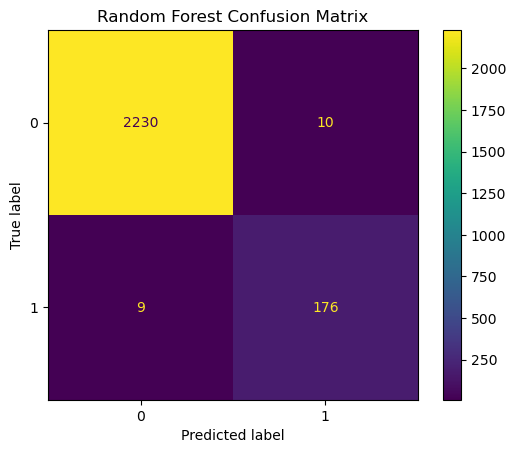

Confusion Matrix:
[[2230   10]
 [   9  176]]


In [27]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# Also print raw confusion matrix values
print("Confusion Matrix:")
print(cm)

#### Interpretation

The confusion matrix shows that the final Random Forest model performs strongly and remains well balanced across both classes.  

It correctly identified **176 out of 185 break pipes**, while only missing **9 actual break cases**. At the same time, it produced only **10 false positives** among **2,240 no-break pipes**, indicating that the model can detect high-risk pipes effectively without generating many unnecessary alerts.

## 10. Plot the Precision-Recall Curve

Because the dataset is imbalanced, the Precision-Recall curve is more informative than accuracy alone.

It shows how precision and recall trade off across different probability thresholds and helps assess how well the model identifies break-risk pipes.

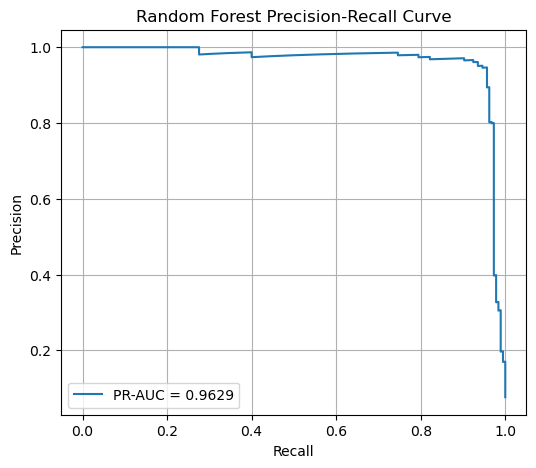

In [30]:
# Compute precision-recall curve values
precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)

# Plot Precision-Recall curve
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test, y_test_prob):.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

#### Interpretation

The Precision-Recall curve remains strong and stable across most recall levels, showing that the Random Forest model maintains high precision while capturing a large proportion of break-risk pipes.

The sharp drop only occurs near the extreme end when forcing recall close to 1.0, which is expected. Overall, the **PR-AUC of 0.9629** confirms that the model performs very well on the minority break class and is suitable for risk prioritisation.

## 11. Feature Importance

### 11.1 Extract Feature Importance Scores

Random Forest provides built-in feature importance scores based on how much each feature helps reduce impurity across the trees.

This gives a first view of which variables contribute most to predicting pipe failure risk.

In [33]:
# Extract feature importance values from the final trained model
feature_importance = pd.DataFrame({
    'feature': X_trainval_enc.columns,
    'importance': final_rf.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(by='importance', ascending=False).reset_index(drop=True)

# Show top 20 most important features
print(feature_importance.head(20))

                    feature  importance
0           condition_score    0.485641
1             shape__length    0.155254
2                  pipe_age    0.097949
3               material_CI    0.046619
4              material_PVC    0.039031
5                 pipe_size    0.018164
6         rel_cleaning_area    0.015516
7               criticality    0.014174
8       pressure_zone_KIT 4    0.009196
9               material_DI    0.008981
10    acquisition_PURCHASED    0.007234
11      acquisition_DONATED    0.007130
12   rel_cleaning_subarea_0    0.007094
13             shallow_main    0.006168
14                  cleaned    0.005035
15     pressure_zone_KIT 2W    0.004114
16  rel_cleaning_subarea_13    0.002676
17      pressure_zone_KIT 6    0.002520
18      pressure_zone_KIT 5    0.002476
19      ownership_KITCHENER    0.002204


#### Interpretation

The Random Forest feature importance results suggest that **pipe condition** is the strongest driver of break risk in the Kitchener dataset, followed by **pipe length**, **pipe age**, and several **material-related variables**. 

This indicates that both asset deterioration factors and physical pipe characteristics play a major role in failure prediction. Network context features such as cleaning area, pressure zone, and criticality also appear to contribute, although to a smaller extent.

### 11.2 Group Feature Importances into Business-Friendly Drivers

Because one-hot encoding splits one business concept into many columns, the next step is to group related encoded features together.

This makes the results easier to interpret at a project level and helps translate them into findings that can later be adapted to Melbourne infrastructure data.

In [36]:
# Group one-hot encoded and related features into higher-level business drivers
grouped_importance = {
    'Condition Score': 0,
    'Pipe Length': 0,
    'Pipe Age': 0,
    'Pipe Size': 0,
    'Material': 0,
    'Pressure Zone': 0,
    'Acquisition': 0,
    'Ownership': 0,
    'Cleaning Area / Subarea': 0,
    'Criticality': 0,
    'Maintenance / Cleaning Indicators': 0,
    'Physical Risk Flags': 0,
    'Category': 0,
    'Lining': 0,
    'Other': 0
}

for _, row in feature_importance.iterrows():
    feature = row['feature']
    importance = row['importance']
    
    if feature == 'condition_score':
        grouped_importance['Condition Score'] += importance
    elif feature == 'shape__length':
        grouped_importance['Pipe Length'] += importance
    elif feature == 'pipe_age':
        grouped_importance['Pipe Age'] += importance
    elif feature == 'pipe_size':
        grouped_importance['Pipe Size'] += importance
    elif feature.startswith('material_'):
        grouped_importance['Material'] += importance
    elif feature.startswith('pressure_zone_'):
        grouped_importance['Pressure Zone'] += importance
    elif feature.startswith('acquisition_'):
        grouped_importance['Acquisition'] += importance
    elif feature.startswith('ownership_'):
        grouped_importance['Ownership'] += importance
    elif feature == 'rel_cleaning_area' or feature.startswith('rel_cleaning_subarea_'):
        grouped_importance['Cleaning Area / Subarea'] += importance
    elif feature == 'criticality':
        grouped_importance['Criticality'] += importance
    elif feature in ['cleaned']:
        grouped_importance['Maintenance / Cleaning Indicators'] += importance
    elif feature in ['bridge_main', 'undersized', 'shallow_main', 'oversized']:
        grouped_importance['Physical Risk Flags'] += importance
    elif feature.startswith('category_'):
        grouped_importance['Category'] += importance
    elif feature == 'lined' or feature.startswith('lined_material_'):
        grouped_importance['Lining'] += importance
    else:
        grouped_importance['Other'] += importance

# Convert grouped importance to dataframe
grouped_importance_df = pd.DataFrame({
    'driver_group': grouped_importance.keys(),
    'importance': grouped_importance.values()
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print(grouped_importance_df)

                         driver_group  importance
0                     Condition Score    0.485641
1                         Pipe Length    0.155254
2                            Material    0.099149
3                            Pipe Age    0.097949
4             Cleaning Area / Subarea    0.074383
5                       Pressure Zone    0.021491
6                           Pipe Size    0.018164
7                         Acquisition    0.014364
8                         Criticality    0.014174
9                 Physical Risk Flags    0.006913
10  Maintenance / Cleaning Indicators    0.005035
11                          Ownership    0.004937
12                             Lining    0.001472
13                           Category    0.001075
14                              Other    0.000000


### Interpretation

After grouping related encoded variables into business-friendly feature categories, the results show that **Condition Score** is by far the strongest driver of pipe break risk in the Random Forest model.

This is followed by **Pipe Length**, **Material**, and **Pipe Age**, suggesting that both asset deterioration and physical pipe characteristics play a major role in failure prediction. 

Operational and network context variables, particularly **Cleaning Area / Subarea**, also contribute meaningfully, while features such as lining, category, and ownership appear to have relatively limited influence in this model.

## 11.3 Plot Grouped Feature Importance

Plotting the grouped importance values makes the findings easier to communicate visually.

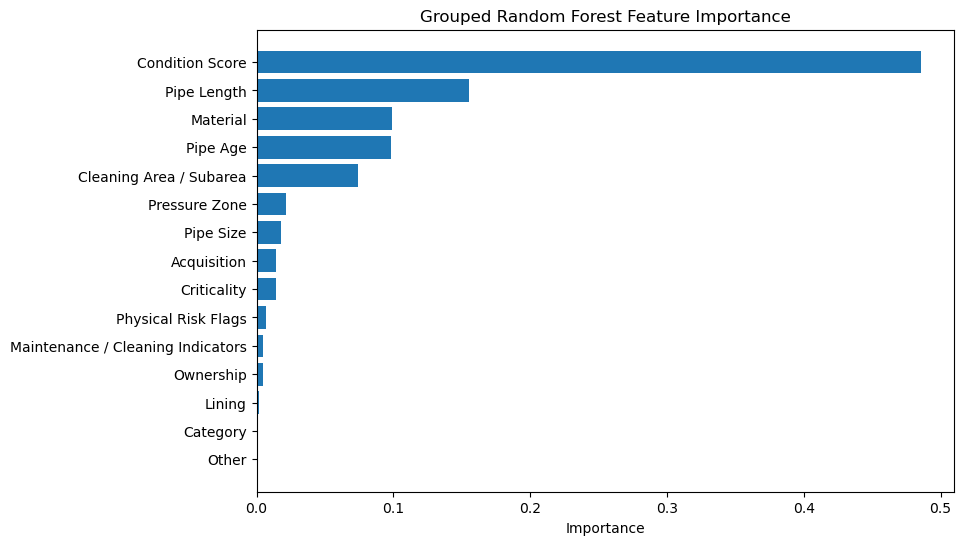

In [39]:
# Sort grouped feature importance for plotting
grouped_plot = grouped_importance_df.sort_values(by='importance', ascending=True)

# Plot grouped feature importance
plt.figure(figsize=(9, 6))
plt.barh(grouped_plot['driver_group'], grouped_plot['importance'])
plt.xlabel("Importance")
plt.title("Grouped Random Forest Feature Importance")
plt.show()

## 12. Conclusion

The final tuned Random Forest model performed very strongly on the unseen test set, achieving:

- **ROC-AUC:** 0.9924
- **PR-AUC:** 0.9629
- **Precision:** 0.9462
- **Recall:** 0.9514
- **F1-score:** 0.9488

The confusion matrix also showed strong and balanced performance, with only a small number of false positives and false negatives. This indicates that the model is effective at identifying high-risk pipes while keeping unnecessary alerts low, making it suitable as an initial **risk identification model** for asset maintenance prioritisation.

In terms of model interpretation, the most important drivers of break risk were:

- **Condition Score**
- **Pipe Length**
- **Material**
- **Pipe Age**
- **Cleaning Area / Subarea**

These results suggest that both **asset deterioration factors** and **physical pipe characteristics** play a major role in failure prediction, while network and operational context also contribute.

Overall, the Random Forest model provides a strong baseline for the capstone project and offers useful insights that can later be compared and adapted to Melbourne-style infrastructure data.

### Relevance for Melbourne water infrastructure

Although this model was trained on the Kitchener dataset, the key findings are still useful for the broader capstone goal of developing a transferable pipe risk identification framework.

The strongest drivers identified here, particularly **Condition Score**, **Pipe Age**, **Material**, **Pipe Length**, and **Pipe Size**, are all infrastructure attributes that are commonly available or can often be derived in other water network datasets, including Melbourne-style asset data.

This means the Random Forest model is valuable not only as a predictive benchmark, but also as a way to identify which asset characteristics should be prioritised when building a local risk scoring system.

These insights can later support a maintenance recommendation workflow, where high-risk pipes are first identified by the model and then passed into a decision-support layer or LLM-based recommendation system for prioritised intervention planning.